# Freight Rate Prediction — Exploratory Data Analysis
Assessment: Machine Learning Engineer (Spotter)

Tujuan notebook ini:
1. Memahami struktur data `train_test.csv`
2. Menemukan isu kualitas data (missing values, anomali)
3. Memahami hubungan antar fitur dan target (`posted_rate`)
4. Menyimpulkan strategi split train/validation dan feature engineering sebelum modeling


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 20)
plt.rcParams['figure.dpi'] = 110

train = pd.read_csv('data/train_test.csv')
val = pd.read_csv('data/validation.csv')
dec_inputs = pd.read_csv('data/december_chart_inputs.csv')

train['date'] = pd.to_datetime(train['date'])
val['date'] = pd.to_datetime(val['date'])
dec_inputs['date'] = pd.to_datetime(dec_inputs['date'])

print("train_test.csv :", train.shape)
print("validation.csv :", val.shape)
print("december_chart_inputs.csv:", dec_inputs.shape)
train.head()

train_test.csv : (48000, 14)
validation.csv : (12000, 13)
december_chart_inputs.csv: (31, 7)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


## 1. Struktur Data & Missing Values

In [2]:
print("=== dtypes ===")
print(train.dtypes)
print()
print("=== missing values (train) ===")
print(train.isna().sum())
print()
print("=== missing values (validation) ===")
print(val.isna().sum())
print()
print("=== duplicate load_id ===")
print("train:", train['load_id'].duplicated().sum(), " | val:", val['load_id'].duplicated().sum())
print("=== fully duplicate rows (excl load_id) ===")
print(train.duplicated(subset=[c for c in train.columns if c != 'load_id']).sum())

=== dtypes ===
load_id                    str
pickup                     str
delivery                   str
pickup_lat             float64
pickup_lon             float64
delivery_lat           float64
delivery_lon           float64
distance               float64
equipment                  str
weight                 float64
date            datetime64[us]
market_index           float64
quote_signal           float64
posted_rate            float64
dtype: object

=== missing values (train) ===
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

=== missing values (validation) ===
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment      

**Temuan:**
- `weight` hilang di 300 baris (0.6%) train, 165 baris di validation.
- `market_index` hilang di 374 baris (0.8%) train, 249 baris di validation — tersebar rata tiap bulan (~0.7-0.9%), kemungkinan **missing-at-random**, bukan karena periode tertentu.
- Tidak ada `load_id` duplikat atau baris duplikat penuh.
- **`december_chart_inputs.csv` TIDAK punya kolom `market_index` dan `quote_signal`** — ini penting: model final harus tetap bisa jalan tanpa dua fitur ini, atau kita perlu strategi estimasi/tanpa-ketergantungan penuh pada fitur tsb untuk skenario Desember.


## 2. Target Variable: `posted_rate`

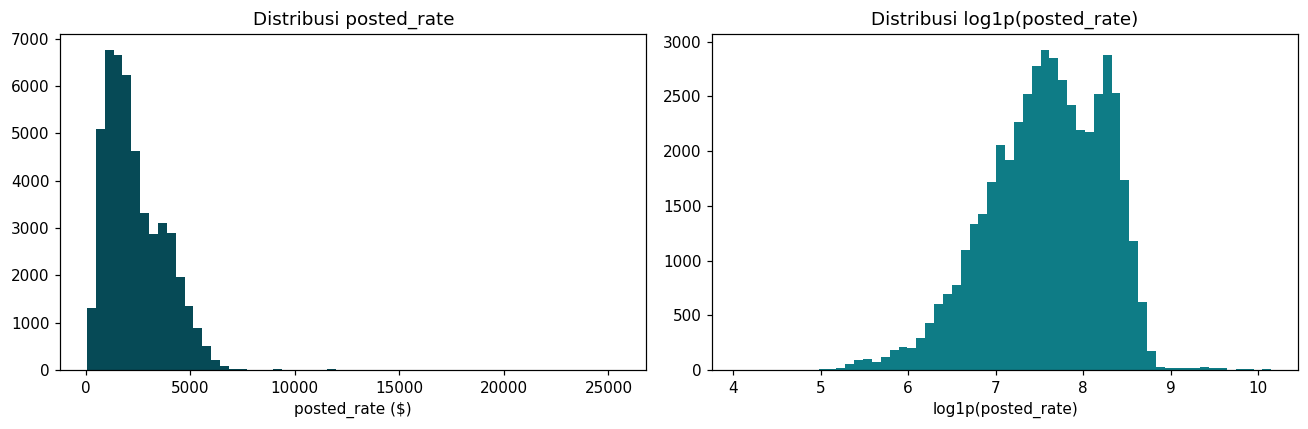

count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train['posted_rate'], bins=60, color='#064A56')
axes[0].set_title('Distribusi posted_rate')
axes[0].set_xlabel('posted_rate ($)')

axes[1].hist(np.log1p(train['posted_rate']), bins=60, color='#0E7C86')
axes[1].set_title('Distribusi log1p(posted_rate)')
axes[1].set_xlabel('log1p(posted_rate)')
plt.tight_layout()
plt.show()

print(train['posted_rate'].describe())

**Temuan:** `posted_rate` right-skewed (khas data harga) → log-transform bikin distribusinya jauh lebih mendekati normal. Ini sinyal kuat untuk **melatih model pada `log1p(posted_rate)`** lalu `expm1` saat prediksi, supaya model tidak terlalu dipengaruhi oleh rute-rute mahal (long-haul) dan errornya proporsional (relevan karena scorer kemungkinan pakai metrik seperti MAPE/RMSE pada skala asli).

## 3. Fitur Numerik: distance, weight, market_index, quote_signal

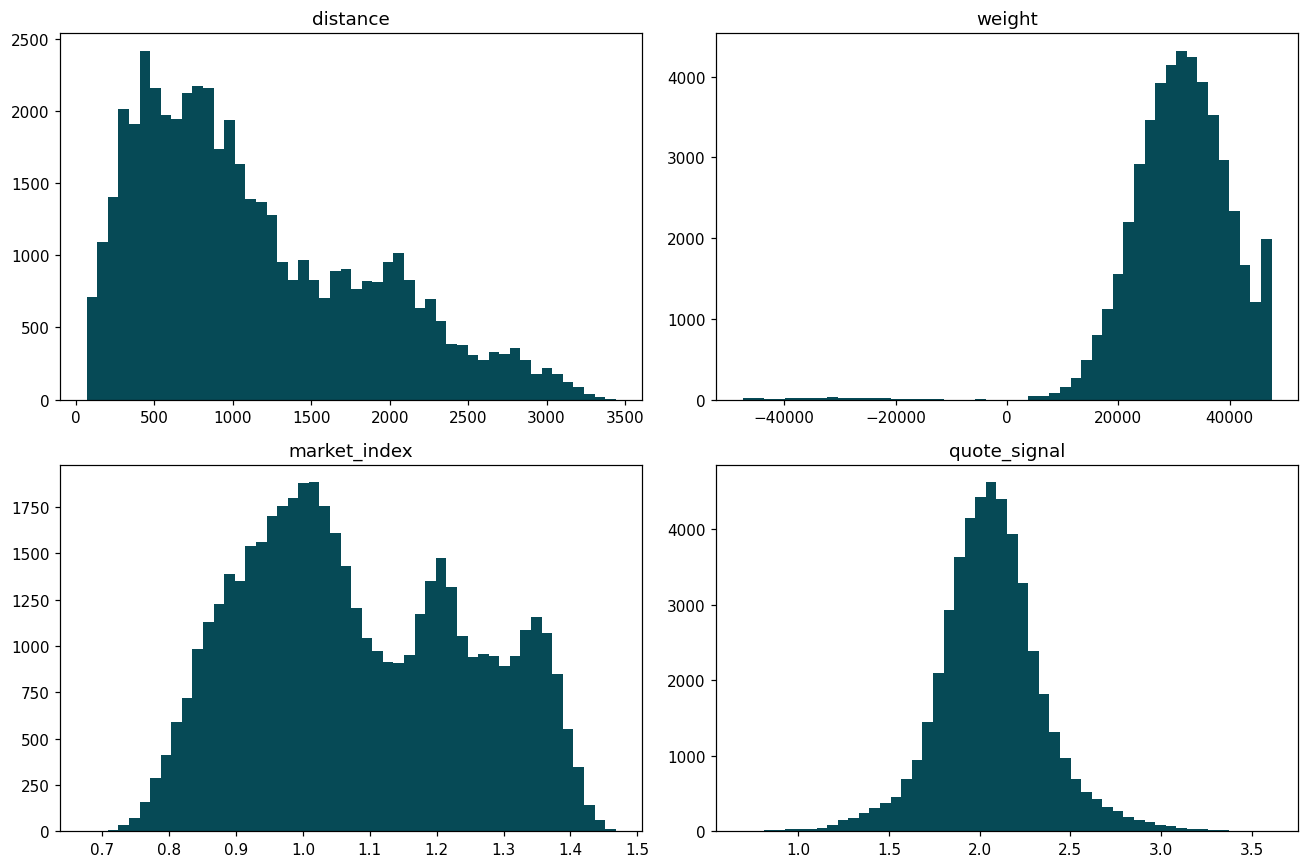

,distance,weight,market_index,quote_signal
count,48000.000000,47700.000000,47626.000000,48000.000000
mean,1135.856654,31028.844004,1.083387,2.062468
std,728.564416,9391.440620,0.168091,0.291391
min,70.000000,-47500.000000,0.676390,0.692280
25%,550.400000,25800.000000,0.949670,1.891030
50%,953.300000,31436.500000,1.055800,2.055750
75%,1645.525000,37018.000000,1.219590,2.221685
max,3439.800000,47500.000000,1.467780,3.610350


In [4]:
num_cols = ['distance', 'weight', 'market_index', 'quote_signal']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, num_cols):
    ax.hist(train[col].dropna(), bins=50, color='#064A56')
    ax.set_title(col)
plt.tight_layout()
plt.show()

train[num_cols].describe()

In [5]:
print("Weight <= 0:", (train['weight'] <= 0).sum(), "dari", train['weight'].notna().sum(), "nilai non-null")
neg = train.loc[train['weight'] < 0, 'weight'].abs()
pos = train.loc[train['weight'] > 0, 'weight']
print("\nDistribusi |weight| utk baris NEGATIF:\n", neg.describe())
print("\nDistribusi weight utk baris POSITIF:\n", pos.describe())

Weight <= 0: 292 dari 47700 nilai non-null

Distribusi |weight| utk baris NEGATIF:
 count      292.000000
mean     31724.195205
std       8262.536326
min       5000.000000
25%      25928.500000
50%      31821.500000
75%      37284.250000
max      47500.000000
Name: weight, dtype: float64

Distribusi weight utk baris POSITIF:
 count    47408.000000
mean     31415.358674
std       7994.902979
min       5000.000000
25%      25922.000000
50%      31493.500000
75%      37063.000000
max      47500.000000
Name: weight, dtype: float64


**Isu kualitas data #1 — `weight` bernilai negatif.**
Ada 292 baris (0.6%) dengan `weight` negatif (mis. -36559). Distribusi *magnitude* (absolut) baris negatif ini **identik** dengan distribusi baris positif (mean ~31.7k vs ~31.4k, range sama 5,000–47,500). Ini bukan outlier riil, melainkan **kesalahan tanda (sign error)** saat input data — kemungkinan besar dari sistem sumber yang keliru mencatat minus.

**Penanganan:** ambil nilai absolut (`abs(weight)`), lalu untuk nilai yang tetap hilang (NaN), isi dengan median per kombinasi `equipment` (karena berat muatan berkorelasi dengan tipe truk).

In [6]:
def haversine(lat1, lon1, lat2, lon2):
    R = 3958.8
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlmb/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

train['hav_distance'] = haversine(train.pickup_lat, train.pickup_lon, train.delivery_lat, train.delivery_lon)
train['dist_ratio'] = train['distance'] / train['hav_distance']

print("Rasio distance (jalan) / haversine (garis lurus):")
print(train['dist_ratio'].describe())
print("\nJumlah baris dgn rasio wajar (1.05 - 1.35, faktor kelokan jalan normal):",
      ((train['dist_ratio'] >= 1.05) & (train['dist_ratio'] <= 1.35)).sum(), "/", len(train))
print("Jumlah baris dgn rasio anomali (>2):", (train['dist_ratio'] > 2).sum())
train.sort_values('dist_ratio', ascending=False)[['pickup','delivery','distance','hav_distance','dist_ratio']].head(5)

Rasio distance (jalan) / haversine (garis lurus):
count    48000.000000
mean         1.194681
std          0.143541
min          1.058090
25%          1.164765
50%          1.182231
75%          1.204765
max          9.634919
Name: dist_ratio, dtype: float64

Jumlah baris dgn rasio wajar (1.05 - 1.35, faktor kelokan jalan normal): 47182 / 48000
Jumlah baris dgn rasio anomali (>2): 22


,pickup,delivery,distance,hav_distance,dist_ratio
37183,Shreveport,New Orleans,70.0,7.26524,9.634919
46059,Shreveport,New Orleans,70.0,7.26524,9.634919
6960,New Orleans,Shreveport,70.0,7.26524,9.634919
15756,Shreveport,New Orleans,70.0,7.26524,9.634919
38469,Shreveport,New Orleans,70.0,7.26524,9.634919


**Isu kualitas data #2 — sedikit rute dengan `distance` tidak konsisten terhadap koordinat.**
98% baris punya rasio jarak-jalan/jarak-lurus 1.05–1.35x (wajar untuk jalan raya AS). Tapi 22 baris (0.05%) punya rasio ekstrem (>2x, bahkan sampai 9.6x) — contoh pasangan Shreveport↔New Orleans yang koordinatnya sangat berdekatan tapi `distance` tercatat 70 mil. Ini kemungkinan **salah input jarak** untuk beberapa rute spesifik.

**Penanganan:** karena jumlahnya sangat kecil (<0.05%) dan `distance` adalah fitur ber-skala besar & paling dominan, baris-baris ini dibiarkan (tidak dihapus, supaya tidak kehilangan kombinasi rute) tapi diberi bobot lebih rendah / diserahkan ke robustness model tree-based (tidak terlalu sensitif ke sedikit outlier). Dicatat sebagai known-issue di laporan.

In [7]:
rpm = train['posted_rate'] / train['distance']
print("Rate-per-mile stats:")
print(rpm.describe())
print("\nBaris dgn rate-per-mile > 10 (ekstrem):", (rpm > 10).sum())
train.loc[rpm > 10, ['pickup','delivery','distance','weight','equipment','posted_rate']].assign(rpm=rpm[rpm>10]).head(10)

Rate-per-mile stats:
count    48000.000000
mean         2.215347
std          0.583887
min          0.333709
25%          1.986974
50%          2.145348
75%          2.342696
max         14.125294
dtype: float64

Baris dgn rate-per-mile > 10 (ekstrem): 49


,pickup,delivery,distance,weight,equipment,posted_rate,rpm
870,Tulsa,Baton Rouge,305.6,26447.0,Reefer,4069.24,13.315576
1415,Montgomery,Birmingham,198.2,25383.0,Reefer,2509.96,12.663774
2469,Tucson,Albuquerque,441.5,47369.0,Flatbed,4989.66,11.301608
4489,Dayton,Harrisburg,476.7,44942.0,Dry Van,5048.45,10.590413
6078,Cincinnati,Lexington,150.4,20990.0,Reefer,1550.14,10.306782
7841,Raleigh,Greensboro,353.0,28610.0,Reefer,4368.67,12.375836
9999,Grand Rapids,Boston,1069.1,29476.0,Reefer,10769.23,10.073174
10173,Chattanooga,Mobile,307.9,30742.0,Flatbed,3624.74,11.772459
11362,Providence,New York,361.0,43114.0,Dry Van,3760.75,10.417590
11713,Fort Wayne,Oklahoma City,1151.3,38377.0,Reefer,12454.19,10.817502


**Isu kualitas data #3 — outlier rate-per-mile.** 49 baris (0.1%) punya rate-per-mile jauh di atas normal (rata-rata ~2.2, ini sampai 14+) — mayoritas di rute jarak pendek (<650 mil) yang biasanya punya rate/mile lebih tinggi karena fixed cost pickup/delivery, tapi beberapa masih di luar wajar. Ini kandidat outlier/anomali harga; akan ditangani lewat **capping (winsorizing) ringan** pada target saat training atau lewat penggunaan model yang robust terhadap outlier (tree-based, loss Huber/quantile).

## 4. Fitur Kategorikal: equipment, kota

equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64

Rate-per-mile rata-rata per equipment:
equipment
Dry Van    2.115401
Flatbed    2.294729
Reefer     2.383376
dtype: float64


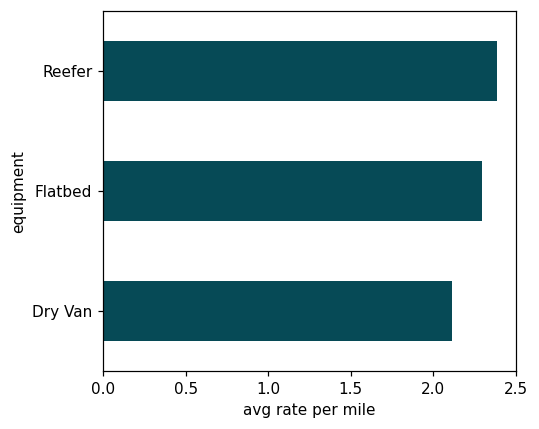

In [8]:
print(train['equipment'].value_counts())
print()
rpm_by_eq = (train['posted_rate']/train['distance']).groupby(train['equipment']).mean().sort_values()
print("Rate-per-mile rata-rata per equipment:")
print(rpm_by_eq)

fig, ax = plt.subplots(figsize=(5,4))
rpm_by_eq.plot(kind='barh', ax=ax, color='#064A56')
ax.set_xlabel('avg rate per mile')
plt.tight_layout()
plt.show()

In [9]:
cities_train = set(train['pickup']) | set(train['delivery'])
cities_val = set(val['pickup']) | set(val['delivery'])
print("Jumlah kota unik di train:", len(cities_train))
print("Jumlah kota unik di validation:", len(cities_val))
print("Kota yang HANYA muncul di validation (tidak ada di train):", cities_val - cities_train)

Jumlah kota unik di train: 64
Jumlah kota unik di validation: 72
Kota yang HANYA muncul di validation (tidak ada di train): {'Knoxville', 'Allentown', 'Laredo', 'Chicago', 'Jackson', 'San Diego', 'Norfolk', 'Charlotte'}


**Temuan penting:** ada 8 kota (Allentown, Jackson, Charlotte, Norfolk, Chicago, San Diego, Laredo, Knoxville) yang muncul di `validation.csv` tapi **tidak pernah muncul** di `train_test.csv`. Artinya encoding kategorikal berbasis nama kota (mis. one-hot / target-encoding per kota) akan menghasilkan *unseen category* saat prediksi validasi.

**Implikasi ke feature engineering:** jangan terlalu bergantung pada identitas kota sebagai kategori diskrit. Lebih aman menggunakan fitur turunan dari koordinat (`pickup_lat/lon`, `delivery_lat/lon`) — misalnya region (grid lat/lon), arah geografis, atau langsung membiarkan model tree menangkap pola dari lat/lon & distance & equipment yang general, ketimbang hafalan nama kota.

## 5. Korelasi Fitur Numerik vs Target

posted_rate     1.000000
distance        0.908519
weight          0.034840
market_index    0.034165
quote_signal   -0.039858
Name: posted_rate, dtype: float64


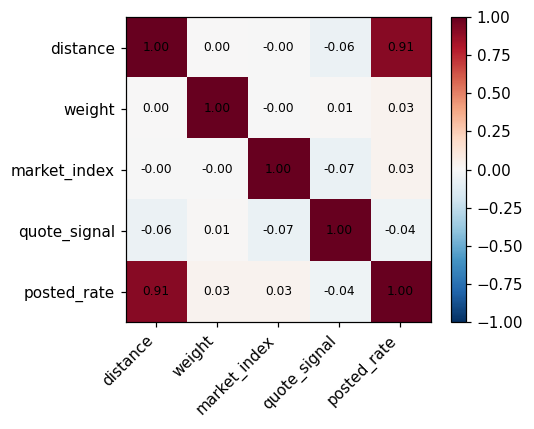

In [10]:
corr_cols = ['distance', 'weight', 'market_index', 'quote_signal', 'posted_rate']
corr = train[corr_cols].corr()
print(corr['posted_rate'].sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha='center', va='center', fontsize=8)
plt.colorbar(im)
plt.tight_layout()
plt.show()

**Temuan:** `distance` mendominasi (korelasi ~0.91 dengan `posted_rate`) — masuk akal, harga freight terutama fungsi dari jarak. `weight`, `market_index`, `quote_signal` korelasi linear langsungnya kecil (<0.05), tapi ini belum tentu berarti tidak berguna — kita cek kontribusinya di luar efek `distance`.

In [11]:
from numpy.linalg import lstsq
X = np.vstack([train['distance'], np.ones(len(train))]).T
coef, *_ = lstsq(X, train['posted_rate'], rcond=None)
resid = train['posted_rate'] - X @ coef

mask = train['market_index'].notna()
print("Korelasi RESIDUAL (posted_rate setelah dikurangi efek distance) dengan:")
print("  market_index :", np.corrcoef(resid[mask], train.loc[mask,'market_index'])[0,1].round(3))
print("  quote_signal :", np.corrcoef(resid, train['quote_signal'])[0,1].round(3))
mask_w = train['weight'].notna()
print("  weight       :", np.corrcoef(resid[mask_w], train.loc[mask_w,'weight'])[0,1].round(3))
print("  Reefer flag  :", np.corrcoef(resid, (train['equipment']=='Reefer').astype(int))[0,1].round(3))
print("  Flatbed flag :", np.corrcoef(resid, (train['equipment']=='Flatbed').astype(int))[0,1].round(3))

Korelasi RESIDUAL (posted_rate setelah dikurangi efek distance) dengan:
  market_index : 0.086
  quote_signal : 0.029
  weight       : 0.078
  Reefer flag  : 0.169
  Flatbed flag : 0.059


**Temuan:** setelah efek `distance` dihilangkan, `equipment` (khususnya Reefer) punya kontribusi paling jelas ke sisa variasi harga (Reefer & Flatbed rate/mile lebih tinggi dari Dry Van — masuk akal karena truk berpendingin & flatbed lebih mahal dioperasikan). `market_index` juga punya kontribusi kecil tapi konsisten. `weight` dan `quote_signal` kontribusi marginalnya sangat kecil secara linear, tapi berpotensi berinteraksi non-linear dengan fitur lain (baru bisa ditangkap model tree/GBM, bukan korelasi linear sederhana).

## 6. Pola Musiman / Waktu (penting untuk prediksi Desember)

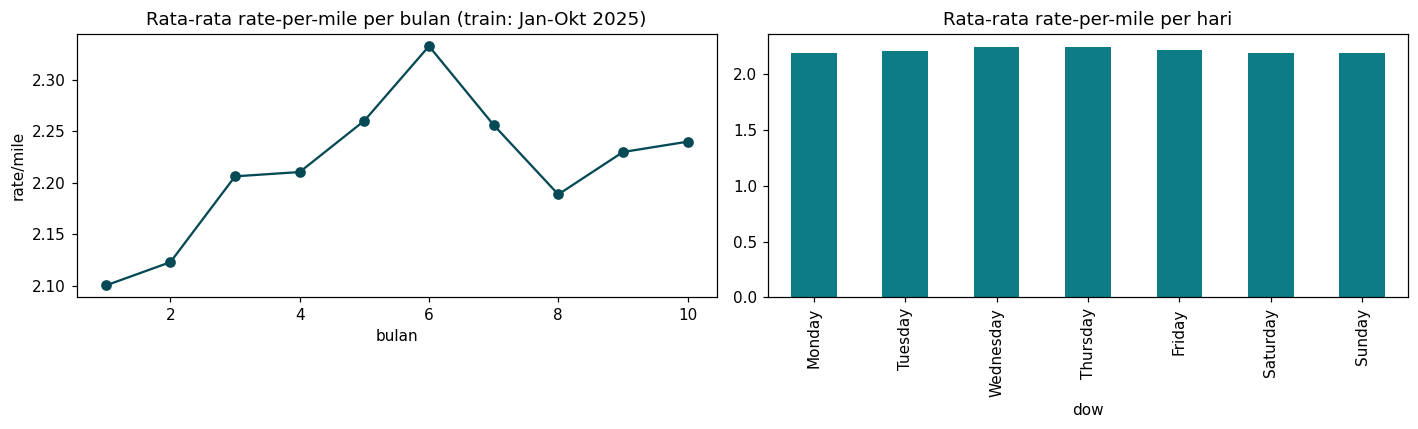

            rpm  market_index
month                        
1      2.100221      0.926696
2      2.122885      0.995997
3      2.206132      1.072880
4      2.210309      1.207649
5      2.260106      1.301452
6      2.332484      1.280316
7      2.255952      1.200893
8      2.188584      0.981480
9      2.229725      0.893039
10     2.239763      0.957502


In [12]:
train['month'] = train['date'].dt.month
train['dow'] = train['date'].dt.day_name()
train['rpm'] = train['posted_rate'] / train['distance']

fig, axes = plt.subplots(1, 2, figsize=(13,4))
train.groupby('month')['rpm'].mean().plot(ax=axes[0], marker='o', color='#064A56')
axes[0].set_title('Rata-rata rate-per-mile per bulan (train: Jan-Okt 2025)')
axes[0].set_xlabel('bulan'); axes[0].set_ylabel('rate/mile')

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
train.groupby('dow')['rpm'].mean().reindex(dow_order).plot(kind='bar', ax=axes[1], color='#0E7C86')
axes[1].set_title('Rata-rata rate-per-mile per hari')
plt.tight_layout()
plt.show()

print(train.groupby('month')[['rpm','market_index']].mean())

**Temuan:**
- Ada **tren musiman** yang jelas: rate/mile naik dari Januari → puncak sekitar Mei-Juni → turun lagi menjelang September-Oktober. `market_index` mengikuti pola serupa (naik lalu turun), konsisten dengan siklus permintaan freight tahunan yang umum di industri (musim panas biasanya volume lebih tinggi).
- Ada efek hari-dalam-minggu yang kecil tapi konsisten (Rabu/Kamis sedikit lebih tinggi dari akhir pekan).
- **Data train berhenti di 31 Oktober 2025**, sedangkan validasi & prediksi Desember jatuh di **November-Desember 2025** — periode yang tidak ada datanya sama sekali di train. Artinya model **harus mengekstrapolasi** tren musiman ini. Solusi: encode tanggal sebagai fitur siklikal (`sin`/`cos` dari hari-dalam-tahun) supaya model bisa menangkap pola musiman berulang dan meng-generalisasi ke bulan yang belum pernah dilihat, alih-alih pakai `month` sebagai kategori diskrit (yang tidak pernah bernilai 11/12 di training).

## 7. Validasi Skema Train vs Validation vs December-Inputs

In [13]:
print("Rentang tanggal train      :", train['date'].min().date(), "-", train['date'].max().date())
print("Rentang tanggal validation  :", val['date'].min().date(), "-", val['date'].max().date())
print("Rentang tanggal december    :", dec_inputs['date'].min().date(), "-", dec_inputs['date'].max().date())
print()
print("Kolom train      :", train.columns.tolist())
print("Kolom validation :", val.columns.tolist())
print("Kolom december    :", dec_inputs.columns.tolist())
print()
print("December inputs — semua baris rute Lexington->Fort Wayne, cek konsistensi fixed fields:")
print(dec_inputs[['pickup','delivery','distance','equipment','weight']].drop_duplicates())

Rentang tanggal train      : 2025-01-01 - 2025-10-31
Rentang tanggal validation  : 2025-11-01 - 2025-12-31
Rentang tanggal december    : 2025-12-01 - 2025-12-31

Kolom train      : ['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate', 'hav_distance', 'dist_ratio', 'month', 'dow', 'rpm']
Kolom validation : ['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal']
Kolom december    : ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']

December inputs — semua baris rute Lexington->Fort Wayne, cek konsistensi fixed fields:
      pickup    delivery  distance equipment  weight
0  Lexington  Fort Wayne       360   Dry Van   32000


**Kesimpulan skema:**
- Train (Jan-Okt 2025) dan Validation (Nov-Des 2025) **tidak overlap sama sekali secara waktu** → ini mengarahkan ke strategi **time-based split** untuk validasi internal (bukan random split), supaya validasi kita meniru kondisi real: model dilatih di masa lalu, diuji ekstrapolasi ke masa depan.
- `december_chart_inputs.csv` hanya berisi 7 kolom (tanpa `pickup_lat/lon`, `delivery_lat/lon`, `market_index`, `quote_signal`) — model final untuk skenario Desember **wajib bisa jalan tanpa fitur-fitur itu**. Koordinat Lexington & Fort Wayne bisa di-lookup dari data train/validation (karena sudah muncul di sana), sehingga fitur geografis tetap bisa direkonstruksi; tapi `market_index`/`quote_signal` benar-benar tidak tersedia untuk Desember → strategi: latih **dua varian fitur** (full-feature utk `validation.csv`, reduced-feature/imputed-trend utk skenario Desember), atau latih satu model yang tidak terlalu bergantung pada dua fitur itu dan mengisi nilainya dengan estimasi tren musiman saat dibutuhkan.

## 8. Ringkasan Temuan → Rencana Modeling

**Data quality issues & penanganan:**
1. `weight` negatif (292 baris) → sign error, ambil `abs()`.
2. `weight` & `market_index` missing (~0.6-0.8%) → imputasi (median per equipment / tren per bulan).
3. 22 baris `distance` tidak konsisten dgn koordinat → dibiarkan (jumlah sangat kecil), model tree robust terhadap ini.
4. 49 baris rate-per-mile ekstrem → capping ringan / robust loss saat training.
5. 8 kota baru di validation yang tak ada di train → jangan over-fit ke identitas kota, andalkan fitur geografis (lat/lon) + distance + equipment.

**Feature engineering plan:**
- `distance`, `weight` (cleaned), `equipment` (one-hot)
- Fitur siklikal tanggal: `sin(2π·doy/365)`, `cos(2π·doy/365)`, `dayofweek`
- `market_index`, `quote_signal` (dengan imputasi utk baris yang hilang / skenario Desember)
- Koordinat pickup/delivery (untuk generalisasi ke kota baru), opsional haversine distance sbg fitur pelengkap `distance`

**Target:** `log1p(posted_rate)` → `expm1` saat inverse predict.

**Split strategy:** time-based split (bukan random) — misal 80% awal (Jan-Agu) untuk training, 20% akhir (Sep-Okt) untuk validasi internal — supaya evaluasi mencerminkan tugas riil (ekstrapolasi ke Nov-Des).

**Model kandidat:** Gradient Boosting (LightGBM/XGBoost) sebagai model utama — robust ke outlier, menangani interaksi non-linear antar fitur (equipment × distance × season) tanpa perlu scaling manual, dan bisa menangani missing value secara native.
